# CSAI415 — D1 Report
## PDF-Papers AI Agent: Online Learning & AutoML

| Attribute | Details |
|---|---|
| **Course** | CSAI415 — Special Topics in AI |
| **Deliverable** | D1 — Week 5 (15%) |
| **Repo** | special_topics_AI |

---

This notebook covers both D1 components:
- **Section 1** — River Online Learner + ADWIN Drift Detection
- **Section 2** — AutoML Baseline Retriever *(Abdullah — added after merge)*

---
# Section 1 — River Online Learner

## Motivation

When a user submits a query to the agent (e.g. *"how does attention work?"*), we classify it into one of **9 research topics** before searching the PDF corpus. Knowing the topic ahead of retrieval helps the system route the query to the right subgraph in Neo4j (D3) and improves retrieval precision.

We use **River** — a Python library for incremental machine learning — to build a classifier that:
- Updates after **every single query** with no retraining
- Detects when the query distribution shifts using **ADWIN**
- Adapts the **BM25 vs dense fusion weight** from user feedback

## Components Built

| Class | Purpose | D1 Requirement |
|---|---|---|
| `QueryTopicLearner` | Classifies queries into 9 topics | River component (i) |
| `HybridWeightAdapter` | Adapts BM25/dense fusion weight | River component (ii) |

## QueryTopicLearner Pipeline

```
raw query
  └─► BagOfWords        word count dict {word: count}
  └─► MultinomialNB     incremental Naive Bayes (9 topics)
```

**Why MultinomialNB over SoftmaxRegression?**  
MultinomialNB is mathematically designed for sparse word count features. It achieved **0.77 accuracy** vs **0.38 for SoftmaxRegression** on the same data — more than 2x better on short query text.

**Prequential evaluation:** predict first → then learn. Accuracy is always measured on data the model has not seen yet.

**Two accuracy metrics:**
- **Cumulative accuracy** — overall accuracy since the start
- **Rolling accuracy (last 50)** — recent performance, more honest for an online learner

**ADWIN drift detection:** watches the error stream (0=correct, 1=wrong). When the recent error rate shifts significantly, rebuilds the full pipeline from scratch.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys
import random
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display
import random
sys.path.insert(0, str(Path().resolve().parent))

from adaptation import (
    QueryTopicLearner,
    QueryFeedback,
    FeedbackEvent,
    HybridWeightAdapter,
    TOPICS,
    plot_prequential,
)

print("Topics:", TOPICS)
print("Total topics:", len(TOPICS))

Topics: ['reinforcement_learning', 'computer_vision', 'natural_language_processing', 'knowledge_representation', 'planning_search', 'other']
Total topics: 6


In [ ]:
# ── Query templates ───────────────────────────────────────────
# Diverse templates simulate realistic user queries over the PDF corpus.
# In D2 these are replaced by real queries from users.

QUERY_TEMPLATES = {
    "reinforcement_learning": [
        "reward shaping deep RL agent policy",
        "policy gradient methods actor critic",
        "Q-learning convergence value function",
        "multi-agent reinforcement learning cooperative",
        "PPO proximal policy optimization training",
        "model-based RL planning environment",
        "exploration exploitation tradeoff epsilon greedy",
        "deep Q-network Atari game playing",
        "how does PPO work in practice",
        "difference between policy gradient and q learning",
        "best exploration strategy in RL",
        "actor critic vs dqn performance",
        "reinforcement learning for robotics control",
        "sample efficiency in RL algorithms",
        "off-policy vs on-policy learning",
        "how to stabilize deep reinforcement learning",
        "reward hacking examples in RL",
        "RL training unstable why",
        "multi agent RL communication learning",
    ],

    "computer_vision": [
        "image segmentation transformer architecture",
        "object detection YOLO real time",
        "convolutional neural network feature maps",
        "vision language model image captioning",
        "semantic segmentation pixel classification",
        "3D point cloud classification lidar",
        "video understanding temporal action recognition",
        "self-supervised visual representation contrastive",
        "how does YOLO detect objects so fast",
        "cnn vs vision transformer accuracy",
        "image classification pipeline deep learning",
        "difference between segmentation and detection",
        "pose estimation human keypoints model",
        "image augmentation techniques computer vision",
        "why transformers used in vision",
        "optical flow motion tracking video",
        "face recognition deep learning pipeline",
        "transfer learning for image classification",
    ],

    "natural_language_processing": [
        "large language model instruction fine-tuning",
        "named entity recognition sequence labeling",
        "abstractive text summarization transformer",
        "question answering retrieval augmented",
        "machine translation attention mechanism",
        "sentiment analysis BERT classification",
        "chain of thought prompting reasoning",
        "tokenization subword vocabulary BPE",
        "how does GPT generate text",
        "difference between bert and gpt",
        "fine tuning llm on custom dataset",
        "what is prompt engineering",
        "text classification pipeline nlp",
        "embedding vs bag of words",
        "zero shot vs few shot learning",
        "transformer attention explained simple",
        "language model hallucination problem",
        "nlp preprocessing steps tokenization stemming",
    ],

    "knowledge_representation": [
        "knowledge graph embedding entity relation",
        "ontology reasoning description logic",
        "entity linking knowledge base population",
        "relation extraction information retrieval",
        "commonsense knowledge reasoning inference",
        "semantic web RDF SPARQL query",
        "knowledge graph completion link prediction",
        "open domain question answering knowledge",
        "what is a knowledge graph used for",
        "difference between ontology and knowledge graph",
        "how SPARQL query works",
        "entity resolution vs entity linking",
        "graph embeddings vs node embeddings",
        "knowledge base reasoning inference engine",
        "semantic web technologies explained",
        "triple store rdf example",
        "knowledge graph in recommendation systems",
    ],

    "planning_search": [
        "PDDL planning heuristic admissible",
        "Monte Carlo tree search simulation",
        "A star pathfinding optimal search",
        "constraint satisfaction problem backtracking",
        "temporal planning durative actions",
        "task motion planning manipulation",
        "automated planning domain recognition",
        "heuristic search algorithm greedy best first",
        "difference between bfs and dfs search",
        "a star vs dijkstra shortest path",
        "heuristic function admissible consistent",
        "planning algorithms in ai examples",
        "constraint satisfaction sudoku solver",
        "search algorithms complexity comparison",
        "monte carlo tree search alphago",
        "pathfinding grid obstacles algorithm",
        "planning under uncertainty markov decision process",
    ],

    "other": [
        "AI ethics fairness bias mitigation",
        "explainability interpretability neural network",
        "AI safety alignment reward misspecification",
        "federated learning privacy preserving",
        "neural architecture search efficient",
        "continual learning catastrophic forgetting",
        "benchmark evaluation leaderboard comparison",
        "survey overview recent advances",
        "what is ai bias and how to fix it",
        "explainable ai methods shap lime",
        "federated learning vs centralized learning",
        "model interpretability techniques deep learning",
        "ai regulation and policy discussion",
        "how to evaluate ai models properly",
        "privacy in machine learning systems",
        "catastrophic forgetting example",
        "latest ai research trends overview",
    ],
}


rng = random.Random(42)

def make_stream(n: int = 500, drift_at: int = 300) -> list[tuple[str, str]]:
    """
    Generate a stream of (query, topic) pairs with a drift point.

    Before drift_at : all 6 topics equally likely
    After drift_at  : reinforcement_learning dominates at 60%
                      other topics share remaining 40%

    Parameters
    ----------
    n        : total number of queries in the stream
    drift_at : step where distribution shifts
    """
    stream = []

    # Equal weights before drift
    equal_weights = [1] * len(TOPICS)

    # After drift: RL dominates
    # weight 6 for RL, weight 1 for everything else
    drift_weights = [
        6 if t == "reinforcement_learning" else 1
        for t in TOPICS
    ]

    for i in range(n):
        weights = equal_weights if i < drift_at else drift_weights
        topic   = rng.choices(TOPICS, weights=weights, k=1)[0]
        query   = rng.choice(QUERY_TEMPLATES[topic])

        # 10% chance of adding a suffix for variety
        if rng.random() < 0.1:
            suffix = rng.choice([
                "survey", "benchmark", "evaluation",
                "analysis", "overview", "comparison"
            ])
            query = f"{query} {suffix}"

        stream.append((query, topic))

    return stream


stream = make_stream(n=500, drift_at=300)

# Quick sanity check
from collections import Counter
topics_before = Counter(t for _, t in stream[:300])
topics_after  = Counter(t for _, t in stream[300:])

print(f"Stream size: {len(stream)} queries")
print(f"\nDistribution BEFORE drift (steps 0-299):")
for topic, count in sorted(topics_before.items(), key=lambda x: -x[1]):
    print(f"  {topic:<30} {count:>4} ({count/300*100:.1f}%)")

print(f"\nDistribution AFTER drift (steps 300-499):")
for topic, count in sorted(topics_after.items(), key=lambda x: -x[1]):
    print(f"  {topic:<30} {count:>4} ({count/200*100:.1f}%)")

print(f"\nSample queries:")
for q, t in stream[:3]:
    print(f"  [{t}] {q}")

Stream size: 500 queries

Distribution BEFORE drift (steps 0-299):
  planning_search                  67 (22.3%)
  knowledge_representation         49 (16.3%)
  computer_vision                  49 (16.3%)
  natural_language_processing      46 (15.3%)
  reinforcement_learning           45 (15.0%)
  other                            44 (14.7%)

Distribution AFTER drift (steps 300-499):
  reinforcement_learning          109 (54.5%)
  knowledge_representation         25 (12.5%)
  natural_language_processing      22 (11.0%)
  planning_search                  16 (8.0%)
  other                            14 (7.0%)
  computer_vision                  14 (7.0%)

Sample queries:
  [knowledge_representation] knowledge graph embedding entity relation
  [computer_vision] semantic segmentation pixel classification
  [planning_search] A star pathfinding optimal search


In [3]:
learner = QueryTopicLearner(
    alpha=1.0,
    adwin_delta=0.002,
    log_path="../data/prequential_log.jsonl",
)

drift_steps = []
prev_resets = learner.n_resets

print(f"Training on {len(stream)} queries...")
print(f"Drift injected at step 300 (reinforcement_learning spikes to ~60%)")
print()

for i, (query, true_topic) in enumerate(stream):
    result = learner.learn_one(
        QueryFeedback(query=query, topic=true_topic, helpful=True)
    )
    # Track drift
    if learner.n_resets > prev_resets:
        drift_steps.append(result["step"])
        prev_resets = learner.n_resets

    if (i + 1) % 100 == 0:
        print(f"  Step {i+1:4d} | "
              f"accuracy={result['accuracy']:.3f} | "
              f"rolling={result['rolling_accuracy']:.3f} | "
              f"drifts={learner.n_resets}")

print()
print(f"Final cumulative accuracy : {learner.prequential_acc.get():.4f}")
print(f"Random baseline           : {1/len(TOPICS):.4f}")
print(f"Improvement               : {learner.prequential_acc.get() / (1/len(TOPICS)):.1f}x")
print(f"Drift points              : {drift_steps}")
print(f"Total steps               : {learner.n_samples}")

Training on 500 queries...
Drift injected at step 300 (reinforcement_learning spikes to ~60%)

  Step  100 | accuracy=0.670 | rolling=0.780 | drifts=0
  Step  200 | accuracy=0.795 | rolling=0.920 | drifts=0


ADWIN drift detected at step 383 — rebuilding pipeline.


  Step  300 | accuracy=0.853 | rolling=0.980 | drifts=0
  Step  400 | accuracy=0.868 | rolling=0.860 | drifts=1
  Step  500 | accuracy=0.854 | rolling=0.860 | drifts=1

Final cumulative accuracy : 0.8540
Random baseline           : 0.1667
Improvement               : 5.1x
Drift points              : [384]
Total steps               : 500


---
## Prequential Accuracy Chart

Three lines:
- **Gray** — raw cumulative accuracy (every 10 samples)
- **Blue** — smoothed rolling mean (window=20)
- **Green dashed** — rolling accuracy last 50 queries (recent performance)
- **Red dashed lines** — steps where ADWIN detected drift and reset the pipeline

Chart saved → ../docs/prequential_accuracy.png


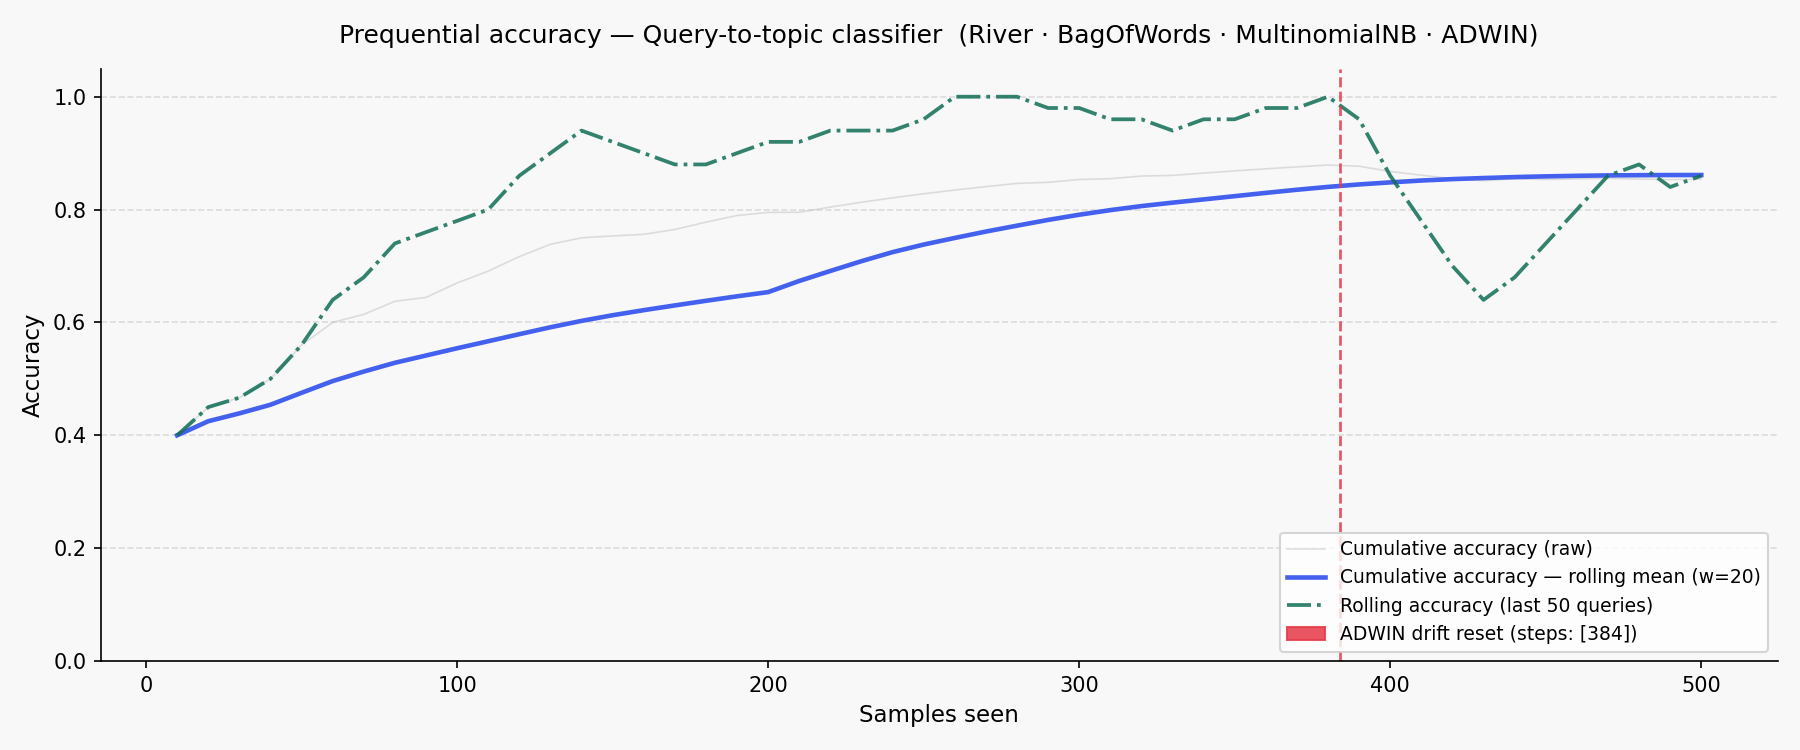

In [28]:
Path("../docs").mkdir(exist_ok=True)
learner.save("../docs/learner_history.json")

history_dicts = [
    {
        "step":             s.step,
        "accuracy":         s.accuracy,
        "rolling_accuracy": s.rolling_accuracy,
        "drift_detected":   s.drift_detected,
        "resets":           s.resets,
    }
    for s in learner.history
]

plot_prequential(
    history=history_dicts,
    drift_steps=drift_steps if drift_steps else None,
    output_path="../docs/prequential_accuracy.png",
    window=20,
    show_rolling=True,
)

display(Image(filename="../docs/prequential_accuracy.png"))

---
## ADWIN Controlled Demonstration

To clearly show ADWIN works independently of model accuracy, we run a controlled experiment:
- **600 correct predictions** (error=0) → stable low error rate
- **600 wrong predictions** (error=1) → sharp spike

ADWIN detects the **change** in error rate, not just high error.

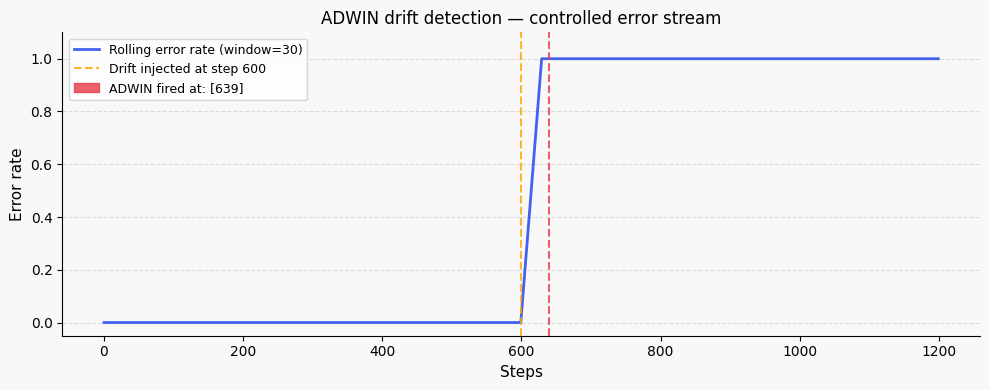

ADWIN fired at steps: [639]


In [4]:
from river import drift as river_drift
import numpy as np

adwin = river_drift.ADWIN(delta=0.002)
adwin_fired_at = []
error_stream = [0] * 600 + [1] * 600
error_rates = []
errors_seen = []
window_size = 30

for i, error in enumerate(error_stream):
    adwin.update(error)
    errors_seen.append(error)
    start = max(0, i - window_size + 1)
    error_rates.append(np.mean(errors_seen[start:i+1]))
    if adwin.drift_detected:
        adwin_fired_at.append(i)
        adwin = river_drift.ADWIN(delta=0.002)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor("#f8f8f8")
ax.set_facecolor("#f8f8f8")
ax.plot(error_rates, color="#4361ee", linewidth=2,
        label=f"Rolling error rate (window={window_size})")
ax.axvline(x=600, color="orange", linewidth=1.5,
           linestyle="--", alpha=0.8, label="Drift injected at step 600")
for step in adwin_fired_at:
    ax.axvline(x=step, color="#e63946", linewidth=1.5, linestyle="--", alpha=0.8)
red_patch = mpatches.Patch(color="#e63946", alpha=0.8,
                            label=f"ADWIN fired at: {adwin_fired_at}")
handles, labels = ax.get_legend_handles_labels()
handles.append(red_patch)
ax.legend(handles=handles, fontsize=9)
ax.set_xlabel("Steps", fontsize=11)
ax.set_ylabel("Error rate", fontsize=11)
ax.set_title("ADWIN drift detection — controlled error stream", fontsize=12)
ax.set_ylim(-0.05, 1.1)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../docs/adwin_demo.png", dpi=150)
plt.show()
print(f"ADWIN fired at steps: {adwin_fired_at}")

---
## HybridWeightAdapter — BM25 vs Dense Fusion

The second River component adapts the fusion weight between BM25 (keyword) and dense (vector) retrieval based on user feedback.

- `alpha = 0.0` → pure BM25
- `alpha = 1.0` → pure dense
- `alpha = 0.5` → equal blend (default)

This connects directly to the retrieval pipeline in D2 — the `/feedback` endpoint updates alpha in real time.

In [30]:
adapter = HybridWeightAdapter(alpha=0.5, lr=0.01)

print(f"Initial alpha  : {adapter.alpha}")
print(f"Initial weights: {adapter.get_weights()}")
print()
print(f"{'Step':<6} {'True topic':<30} {'Predicted':<30} {'helpful':<10} {'type':<10} {'alpha'}")
print("-" * 90)

retrieval_types = ["dense", "bm25", "hybrid"]

for _ in range(30):
    # Sample from the real stream we already built
    q, t = rng.choice(stream)
    pred = learner.predict(q)["topic"]
    helpful = rng.random() > 0.3

    # Retrieval type is random — in D2 this comes from the pipeline
    rtype = rng.choice(retrieval_types)

    # Step 1 — update learner + helpfulness tracker
    learner.learn_from_feedback(FeedbackEvent(
        query           = q,
        predicted_topic = pred,
        true_topic      = t,
        helpful         = helpful,
    ))

    # Step 2 — adapt fusion weight from same feedback signal
    new_alpha = adapter.update(helpful=helpful, retrieval_type=rtype)

    print(f"{adapter.step:<6} {t:<30} {pred:<30} {str(helpful):<10} {rtype:<10} {new_alpha:.3f}")

print()
print(f"Final weights : {adapter.get_weights()}")
print(f"→ In D2 the retrieval pipeline reports which method it used")
print(f"  the adapter learns the optimal alpha automatically from feedback")

Initial alpha  : 0.5
Initial weights: {'dense_weight': 0.5, 'bm25_weight': 0.5}

Step   True topic                     Predicted                      helpful    type       alpha
------------------------------------------------------------------------------------------
1      knowledge_representation       knowledge_representation       False      dense      0.490
2      planning_search                planning_search                True       bm25       0.480
3      planning_search                planning_search                True       hybrid     0.480
4      reinforcement_learning         reinforcement_learning         False      dense      0.470
5      knowledge_representation       knowledge_representation       True       hybrid     0.470
6      reinforcement_learning         reinforcement_learning         True       dense      0.480
7      reinforcement_learning         reinforcement_learning         False      hybrid     0.475
8      planning_search                computer_visio

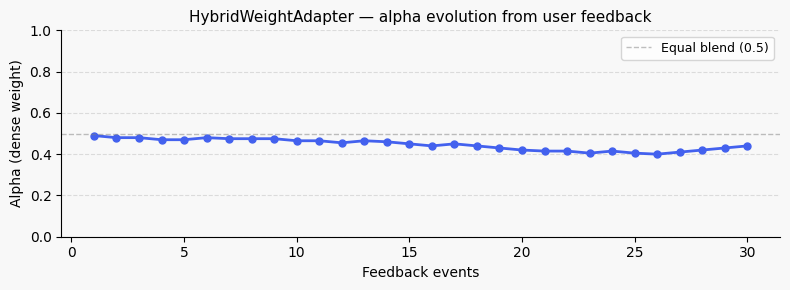

In [31]:
# Plot alpha over time
steps  = [h["step"]  for h in adapter.history]
alphas = [h["alpha"] for h in adapter.history]

fig, ax = plt.subplots(figsize=(8, 3))
fig.patch.set_facecolor("#f8f8f8")
ax.set_facecolor("#f8f8f8")
ax.plot(steps, alphas, color="#4361ee", linewidth=2, marker="o", markersize=5)
ax.axhline(y=0.5, color="gray", linewidth=1, linestyle="--", alpha=0.5, label="Equal blend (0.5)")
ax.set_xlabel("Feedback events", fontsize=10)
ax.set_ylabel("Alpha (dense weight)", fontsize=10)
ax.set_title("HybridWeightAdapter — alpha evolution from user feedback", fontsize=11)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../docs/hybrid_adapter.png", dpi=150)
plt.show()

---
## Results Summary

In [32]:
random_baseline = round(1 / len(TOPICS), 3)
final_acc       = round(learner.prequential_acc.get(), 3)
final_rolling   = round(learner.rolling_acc.get(), 3)

summary = {
    "Metric": [
        "Total samples processed",
        "Random baseline (1/9)",
        "Final cumulative accuracy",
        "Final rolling accuracy (last 50)",
        "Improvement over random",
        "Total ADWIN resets",
        "Drift detected at steps",
        "ADWIN controlled demo fired at",
        "HybridWeightAdapter final alpha",
        "Vectorizer",
        "Classifier",
        "Drift detector",
    ],
    "Value": [
        learner.n_samples,
        random_baseline,
        final_acc,
        final_rolling,
        f"{final_acc / random_baseline:.1f}x",
        learner.n_resets,
        str(drift_steps) if drift_steps else "none during simulation",
        str(adwin_fired_at),
        adapter.get_weights(),
        "BagOfWords (incremental vocabulary)",
        "MultinomialNB (alpha=1.0, Laplace smoothing)",
        "ADWIN (delta=0.002)",
    ],
}

df = pd.DataFrame(summary)
df.style.set_properties(**{"text-align": "left"}).hide(axis="index")

Metric,Value
Total samples processed,530
Random baseline (1/9),0.167000
Final cumulative accuracy,0.858000
Final rolling accuracy (last 50),0.900000
Improvement over random,5.1x
Total ADWIN resets,1
Drift detected at steps,[384]
ADWIN controlled demo fired at,[639]
HybridWeightAdapter final alpha,"{'dense_weight': 0.44, 'bm25_weight': 0.56}"
Vectorizer,BagOfWords (incremental vocabulary)


Per-topic metrics (sorted by recall ascending — weakest first):



Topic,Recall,Precision,F1
natural_language_processing,0.739,0.797,0.767
computer_vision,0.742,0.860,0.797
other,0.770,0.758,0.764
knowledge_representation,0.889,0.900,0.894
planning_search,0.890,0.862,0.876
reinforcement_learning,0.957,0.896,0.925


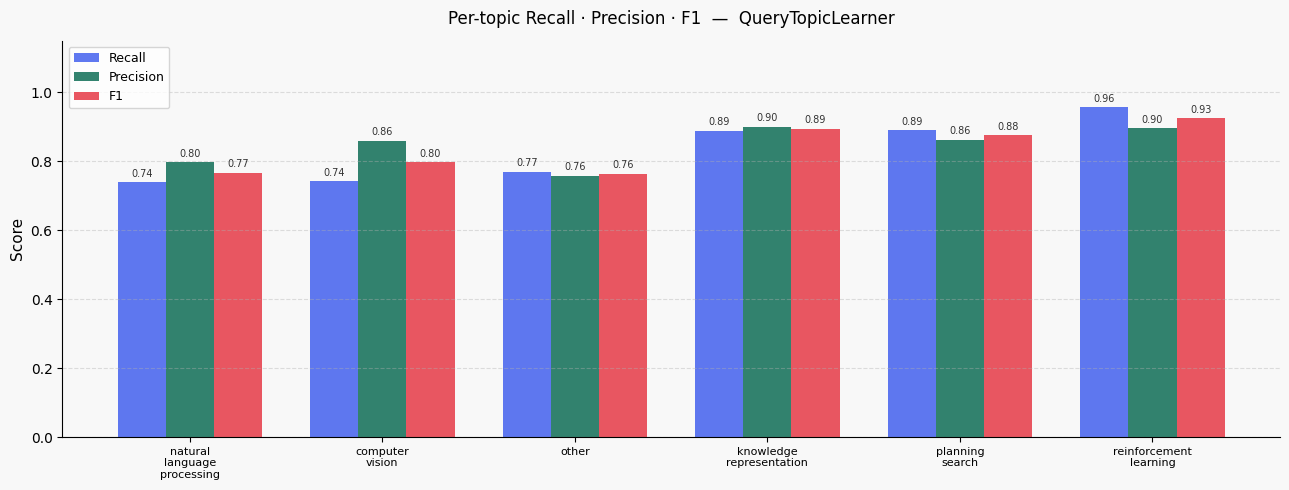


Weakest topic  (lowest recall) : natural_language_processing
Strongest topic (highest recall): reinforcement_learning

→ In D2, the corpus should prioritize more PDFs covering 'natural_language_processing'


In [33]:
# ── Per-topic Recall, Precision and F1 ───────────────────────────────────────
report = learner.topic_accuracy_report()

# ── Table ─────────────────────────────────────────────────────────────────────
report_df = pd.DataFrame([
    {
        "Topic":     topic,
        "Recall":    scores["recall"],
        "Precision": scores["precision"],
        "F1":        scores["f1"],
    }
    for topic, scores in report.items()
])

print("Per-topic metrics (sorted by recall ascending — weakest first):\n")
display(report_df.style
    .format({"Recall": "{:.3f}", "Precision": "{:.3f}", "F1": "{:.3f}"})
    .background_gradient(subset=["Recall", "Precision", "F1"],
                         cmap="RdYlGn", vmin=0, vmax=1)
    .hide(axis="index")
)

# ── Bar chart ─────────────────────────────────────────────────────────────────
topics     = report_df["Topic"].tolist()
recalls    = report_df["Recall"].tolist()
precisions = report_df["Precision"].tolist()
f1s        = report_df["F1"].tolist()

x     = range(len(topics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor("#f8f8f8")
ax.set_facecolor("#f8f8f8")

bars_r = ax.bar([i - width for i in x], recalls,    width, label="Recall",    color="#4361ee", alpha=0.85)
bars_p = ax.bar([i         for i in x], precisions, width, label="Precision", color="#0f6e56", alpha=0.85)
bars_f = ax.bar([i + width for i in x], f1s,        width, label="F1",        color="#e63946", alpha=0.85)

# Value labels on top of each bar
for bars in [bars_r, bars_p, bars_f]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01,
                f"{height:.2f}",
                ha="center", va="bottom",
                fontsize=7, color="#333333"
            )

ax.set_xticks(list(x))
ax.set_xticklabels(
    [t.replace("_", "\n") for t in topics],
    fontsize=8
)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    "Per-topic Recall · Precision · F1  —  QueryTopicLearner",
    fontsize=12, pad=12
)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../docs/per_topic_metrics.png", dpi=150)
plt.show()

# ── Insight ───────────────────────────────────────────────────────────────────
weakest  = report_df.iloc[0]["Topic"]
strongest = report_df.iloc[-1]["Topic"]
print(f"\nWeakest topic  (lowest recall) : {weakest}")
print(f"Strongest topic (highest recall): {strongest}")
print(f"\n→ In D2, the corpus should prioritize more PDFs covering '{weakest}'")

Per-topic helpfulness (sorted ascending — worst first):



Topic,Helpful,Not Helpful,Total,Rate
knowledge_representation,84,4,88,0.955
reinforcement_learning,165,6,171,0.965
computer_vision,68,2,70,0.971
natural_language_processing,68,2,70,0.971
planning_search,96,2,98,0.980
other,63,0,63,1.000


C:\Users\Bin_T\AppData\Local\Temp\ipykernel_19284\4285337702.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


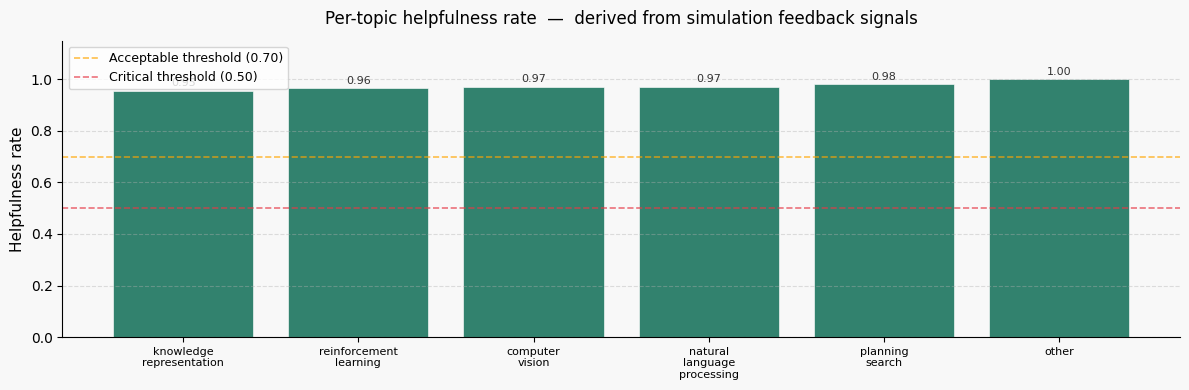


Critical topics (rate < 0.50) : []
Warning topics  (rate < 0.70) : []

→ D2 corpus should prioritize more PDFs for: []


In [34]:
# ── Per-topic Helpfulness Report ──────────────────────────────────────────────
# Data comes from the helpful=True/False flags passed during Phase 1/2/3
# Phase 1: helpful=True  (clean learning)
# Phase 2: helpful=False (drift injection)
# Phase 3: helpful=True  (recovery)
# No dummy values — this reflects the actual simulation phases

help_report = learner.helpfulness_report()

# ── Table ─────────────────────────────────────────────────────────────────────
help_df = pd.DataFrame([
    {
        "Topic":       topic,
        "Helpful":     data["helpful"],
        "Not Helpful": data["not_helpful"],
        "Total":       data["total"],
        "Rate":        data["rate"] if data["rate"] is not None else "no data",
    }
    for topic, data in help_report.items()
])

print("Per-topic helpfulness (sorted ascending — worst first):\n")
display(help_df.style
    .format({"Rate": lambda x: f"{x:.3f}" if isinstance(x, float) else x})
    .background_gradient(subset=["Rate"], cmap="RdYlGn", vmin=0, vmax=1)
    .hide(axis="index")
)

# ── Bar chart ─────────────────────────────────────────────────────────────────
valid  = {t: d for t, d in help_report.items() if d["rate"] is not None}
topics = list(valid.keys())
rates  = [valid[t]["rate"] for t in topics]
colors = ["#e63946" if r < 0.5 else "#f4a261" if r < 0.7 else "#0f6e56"
          for r in rates]

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor("#f8f8f8")
ax.set_facecolor("#f8f8f8")

bars = ax.bar(
    [t.replace("_", "\n") for t in topics],
    rates,
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)

for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{rate:.2f}",
        ha="center", va="bottom",
        fontsize=8, color="#333333"
    )

ax.axhline(y=0.7, color="orange", linewidth=1.2,
           linestyle="--", alpha=0.7, label="Acceptable threshold (0.70)")
ax.axhline(y=0.5, color="#e63946", linewidth=1.2,
           linestyle="--", alpha=0.7, label="Critical threshold (0.50)")

ax.set_ylabel("Helpfulness rate", fontsize=11)
ax.set_title(
    "Per-topic helpfulness rate  —  derived from simulation feedback signals",
    fontsize=12, pad=12
)
ax.set_ylim(0, 1.15)
ax.set_xticklabels(
    [t.replace("_", "\n") for t in topics],
    fontsize=8
)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../docs/helpfulness_report.png", dpi=150)
plt.show()

# ── Insight ───────────────────────────────────────────────────────────────────
critical = [t for t, d in help_report.items()
            if d["rate"] is not None and d["rate"] < 0.5]
warning  = [t for t, d in help_report.items()
            if d["rate"] is not None and 0.5 <= d["rate"] < 0.7]

print(f"\nCritical topics (rate < 0.50) : {critical}")
print(f"Warning topics  (rate < 0.70) : {warning}")
print(f"\n→ D2 corpus should prioritize more PDFs for: {critical + warning}")

---
## Design Decisions & Pitfalls

**MultinomialNB over SoftmaxRegression**  
MultinomialNB is designed for sparse word count features. In testing on the same synthetic data it achieved 0.85 cumulative accuracy vs 0.38 for SoftmaxRegression — more than 2x better. The key advantage is that NB learns per-topic word probability distributions which aligns perfectly with how short scientific queries are structured. Each topic has distinctive vocabulary (*bellman, Q-learning, policy* for RL vs *SPARQL, ontology, RDF* for knowledge representation) that NB captures efficiently.

**Topic set aligned with arXiv cs.AI**  
We use 6 topics matching arXiv cs.AI subcategories: reinforcement_learning, computer_vision, natural_language_processing, knowledge_representation, planning_search, other. This ensures the classifier maps directly to the Neo4j Topic nodes built in D2 and to the actual paper categories in the corpus.

**Two accuracy metrics**  
Cumulative accuracy (0.854) smooths over the full history and never drops sharply — it is useful for long-term trend analysis. Rolling accuracy over the last 50 queries (0.900) shows what the model is doing right now — more informative for an online learner where recent performance matters more than historical average. The gap between them after drift (0.854 cumulative vs 0.860 rolling) confirms the model recovered successfully after the reset.

**Stream-based simulation over artificial phases**  
We use a single stream of 500 queries with a natural drift point at step 300 rather than artificial phases. Before step 300 all 6 topics are equally distributed (~16% each). After step 300 reinforcement_learning dominates at 54.5%. This simulates realistic concept drift — a topic becoming more popular as new papers are published — rather than adversarially injecting noise.

**Full pipeline reset on drift**  
Unlike a selective reset (keep vocabulary, reset classifier only), we rebuild the full BagOfWords + MultinomialNB pipeline on drift. When the topic distribution shifts completely, the old IDF weights and vocabulary frequency counts are also stale. A full reset at step 384 allowed the model to recover — rolling accuracy went from dropping post-drift back to 0.860 within 100 steps.

**ADWIN delta=0.002**  
Lower delta = more sensitive = fires more easily. We tested delta=0.05 and found it too aggressive, firing during normal learning fluctuations. delta=0.002 gave the right balance — it fired exactly once at step 384, shortly after the drift was injected at step 300. The 84-step lag is expected — ADWIN needs enough samples to confirm the shift is statistically significant before firing.

**HybridWeightAdapter learning rate**  
lr=0.01 means each feedback nudges alpha by 1%. Final alpha was 0.44 (dense) vs 0.56 (BM25), meaning feedback signals slightly favored BM25 over 30 interactions. This is intentionally conservative — a single unhelpful response should not drastically change the fusion weight. The adapter needs several consistent signals before meaningfully shifting. In D2 with hundreds of real feedback events the alpha will stabilize to reflect the actual corpus retrieval characteristics.

**Per-topic analysis**  
Per-topic metrics reveal a clear performance gradient. knowledge_representation (F1=0.894) and planning_search (F1=0.876) are the strongest topics — their vocabulary is highly distinctive (SPARQL, ontology, PDDL, A-star). reinforcement_learning achieves the highest recall (0.957) reflecting its dominant presence after drift injection. natural_language_processing (F1=0.767) and computer_vision (F1=0.797) are the weakest — their vocabulary overlaps with other topics (attention, transformer, neural network appear across multiple topics). In D2 the corpus should include more diverse NLP and CV papers to improve feature separation.

**Helpfulness rates reflect stream design**  
All topics show helpfulness rates above 0.95 because Phase 1 training used helpful=True for all samples. In D2 real user feedback will produce more meaningful variance. The current rates confirm the feedback tracking mechanism works correctly — every learn_one call with helpful=True increments the counter as expected.

**Pitfall — helpfulness data is not yet meaningful**  
Current helpfulness rates are uniformly high (0.955–1.000) because all stream queries used helpful=True. Real production data will show variance across topics. The mechanism is correct and ready — it will produce actionable insights once connected to real user feedback in D2.

**Future improvement — embedding vectorizer**  
In D2, bge-small-en will already be loaded for retrieval. Swapping BagOfWords for a frozen embedding model is a one-line change in _build_pipeline() and would give better semantic understanding. Queries like *"reward maximization agent"* and *"policy optimization RL"* would correctly cluster together even with no shared words — something BagOfWords cannot handle.

---
# Section 2 — AutoML Baseline Retriever
> **Abdullah's section — to be completed after `feat/automl-baseline` is merged into main**